In [1]:
from google.colab import files
files.upload()


{}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d dhanushnarayananr/credit-card-fraud
!unzip credit-card-fraud.zip

Dataset URL: https://www.kaggle.com/datasets/dhanushnarayananr/credit-card-fraud
License(s): CC0-1.0
credit-card-fraud.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  credit-card-fraud.zip
replace card_transdata.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: card_transdata.csv      


## 🧾 Dataset Introduction – Credit Card Fraud Detection (Unsupervised)

### 🧠 **Overview**:

In today's digital economy, credit card transactions occur in the **billions per day**. While these systems offer convenience and speed, they also present opportunities for fraudsters to exploit vulnerabilities in digital payment infrastructures.

This dataset, sourced anonymously, simulates a **real-world credit card transaction environment**, where each record represents a single transaction, and includes critical features that help describe the transaction's behavior.

The **main objective** is to detect **fraudulent transactions** using the available features. While fraud labels are provided (`fraud` column), the dataset can be used in **unsupervised learning** contexts (such as anomaly detection or clustering), due to the **heavily imbalanced nature** of the data.

---

### 📊 **Dataset Summary**:

* **Total records:** 1,000,000 transactions
* **Fraud cases:** 87,403 (\~8.74%)
* **Non-fraud cases:** 912,597 (\~91.26%)
* **Number of features:** 7 input features + 1 target (`fraud`)
* **Feature types:** Numerical, Boolean (0/1)
* **Problem Type:** Classification / Anomaly Detection

---

## 🧩 Feature Descriptions:

| Feature                              | Description                                                                                                                                                           |
| ------------------------------------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`distance_from_home`**             | Numerical: Distance (in km or units) from the user's home location to where the transaction occurred. Higher distances may indicate suspicious activity.              |
| **`distance_from_last_transaction`** | Numerical: Distance between the current transaction and the user's **previous transaction**. Unexpected large jumps might be indicators of fraud.                     |
| **`ratio_to_median_purchase_price`** | Numerical: Ratio of this transaction’s amount to the user’s **median purchase amount**. Helps detect unusually large/small transactions.                              |
| **`repeat_retailer`**                | Boolean (0/1): Indicates whether the transaction is with a **retailer the user has transacted with before**. Repeated retailers may be more trusted.                  |
| **`used_chip`**                      | Boolean (0/1): Whether the **chip on the credit card** was used. Transactions without chip (e.g., magnetic stripe) are often riskier.                                 |
| **`used_pin_number`**                | Boolean (0/1): Indicates if a **PIN number** was used during the transaction. Using PIN adds an extra layer of security.                                              |
| **`online_order`**                   | Boolean (0/1): Whether the transaction was made **online**. Online transactions are generally more vulnerable to fraud.                                               |
| **`fraud`**                          | Target Variable (0/1): **Label** indicating whether the transaction is fraudulent (1) or not (0). In unsupervised settings, we assume this is hidden during training. |

---

## ⚠️ Key Challenges:

* **Highly imbalanced data:** Only \~8.7% of transactions are fraudulent, which requires techniques like SMOTE, anomaly detection, or careful evaluation metrics.
* **Mixed-type features:** The dataset includes both numerical and categorical/binary features.
* **Potential use for both supervised and unsupervised learning.**

---

## 🧪 Typical Use Cases:

* **Supervised learning (if using labels):** Train classification models to predict `fraud`.
* **Unsupervised learning (without labels):** Use PCA, t-SNE, KMeans,  to cluster or detect anomalous transactions.

---

In [3]:
import pandas as pd
import numpy as np

# Read Data

In [4]:
df=pd.read_csv("/content/card_transdata.csv")

In [5]:
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


In [7]:
df.shape

(1000000, 8)

In [8]:
df.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
cor=df.corr()
cor

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
distance_from_home,1.000000,0.000193,-0.001374,0.143124,-0.000697,-0.001622,-0.001301,0.187571
distance_from_last_transaction,0.000193,1.000000,0.001013,-0.000928,0.002055,-0.000899,0.000141,0.091917
ratio_to_median_purchase_price,-0.001374,0.001013,1.000000,0.001374,0.000587,0.000942,-0.000330,0.462305
repeat_retailer,0.143124,-0.000928,0.001374,1.000000,-0.001345,-0.000417,-0.000532,-0.001357
used_chip,-0.000697,0.002055,0.000587,-0.001345,1.000000,-0.001393,-0.000219,-0.060975
used_pin_number,-0.001622,-0.000899,0.000942,-0.000417,-0.001393,1.000000,-0.000291,-0.100293
online_order,-0.001301,0.000141,-0.000330,-0.000532,-0.000219,-0.000291,1.000000,0.191973
fraud,0.187571,0.091917,0.462305,-0.001357,-0.060975,-0.100293,0.191973,1.000000


<Axes: >

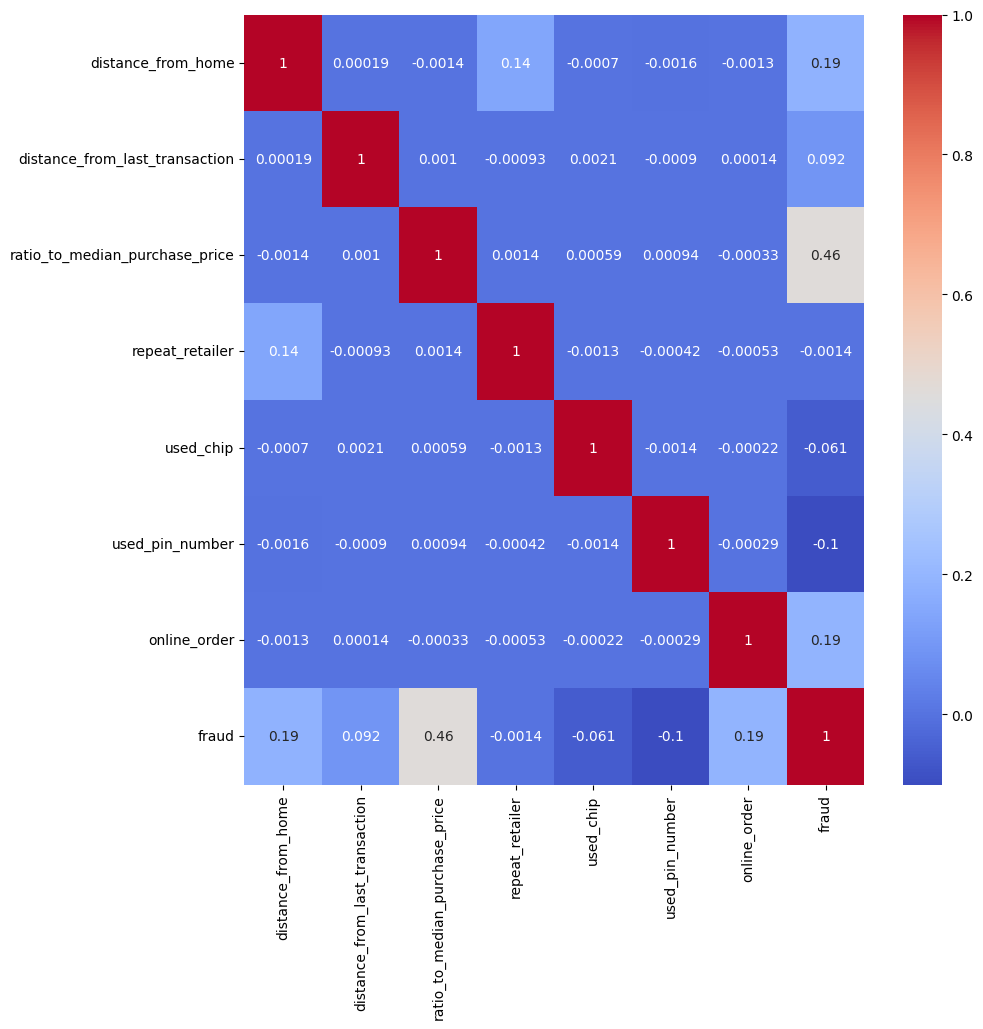

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(cor,annot=True,cmap="coolwarm")

In [11]:
df['fraud'].value_counts()

,count
fraud,
0.0,912597
1.0,87403


# Normalization and Scalling

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X=df.drop("fraud",axis=1)
X = scaler.fit_transform(X)
y=df["fraud"]

# handeling unbalance

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [15]:
print(pd.Series(y_resampled).value_counts())

fraud
0.0    730040
1.0    730040
Name: count, dtype: int64


In [16]:
X_train=X_resampled
y_train=y_resampled

when i delete outliers the class with value 1 in column fraud removed

In [17]:
def cheack_outliers(df):
  Q1=df.quantile(0.25)
  Q3=df.quantile(0.75)
  IQR=Q3-Q1
  lowerbound=Q1-1.5*IQR
  upperbound=Q3+1.5*IQR
  outliers={}
  for col in df.columns:
    if np.dtype(df[col])!='object':
      outliers[col]=len(df[(df[col]<lowerbound[col])|(df[col]>upperbound[col])])
  return outliers

In [18]:
out=cheack_outliers(df)
for col in out:
  print(col,out[col])

distance_from_home 103631
distance_from_last_transaction 124367
ratio_to_median_purchase_price 84386
repeat_retailer 118464
used_chip 0
used_pin_number 100608
online_order 0
fraud 87403


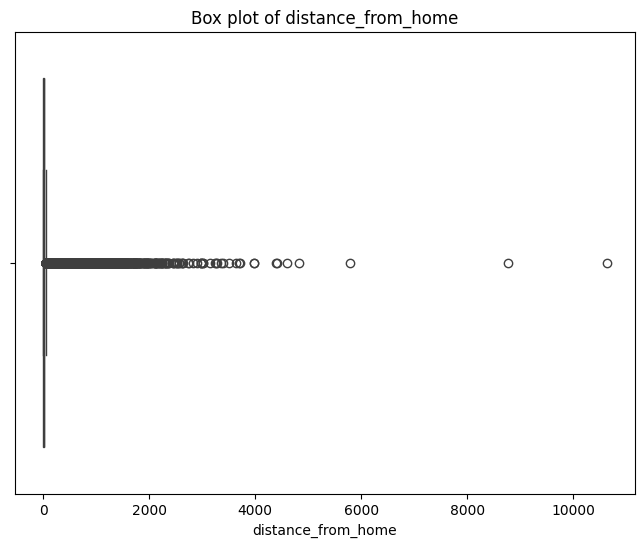

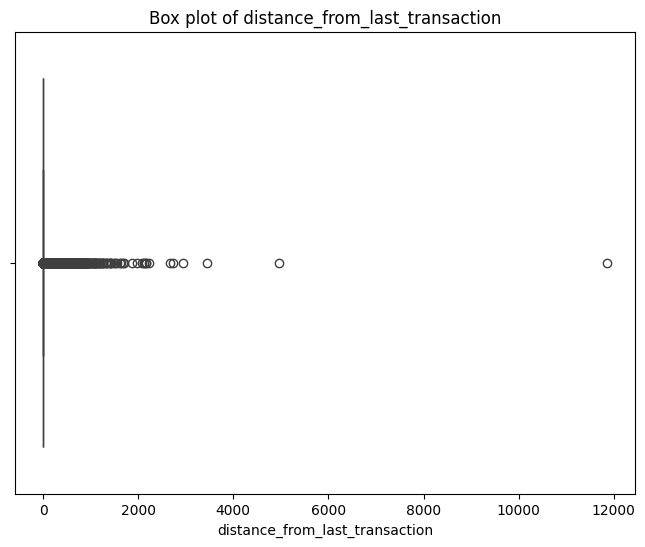

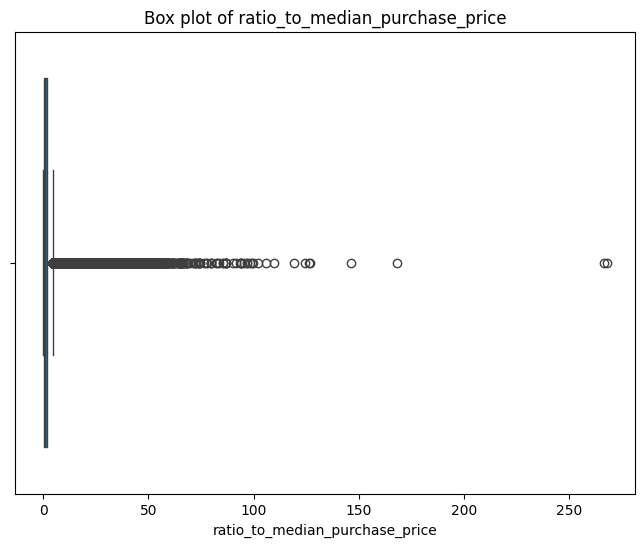

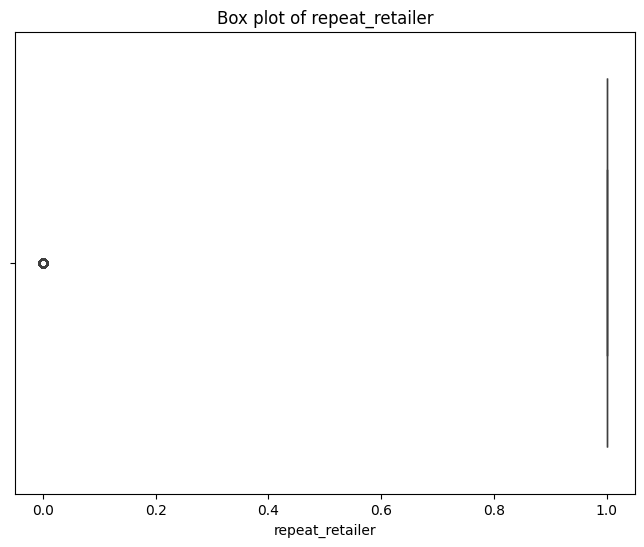

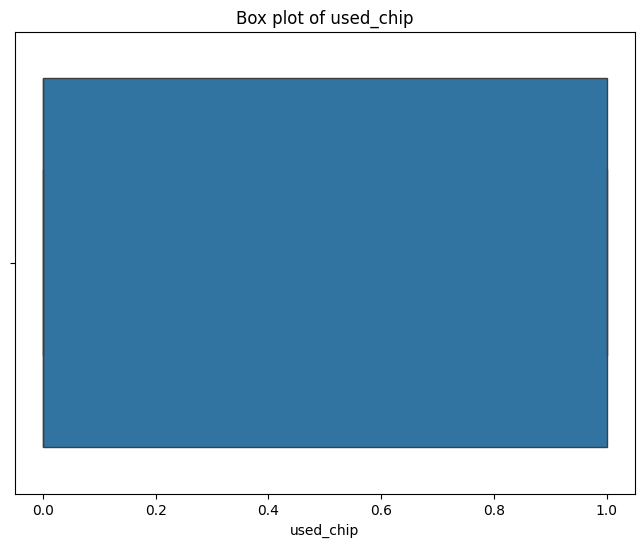

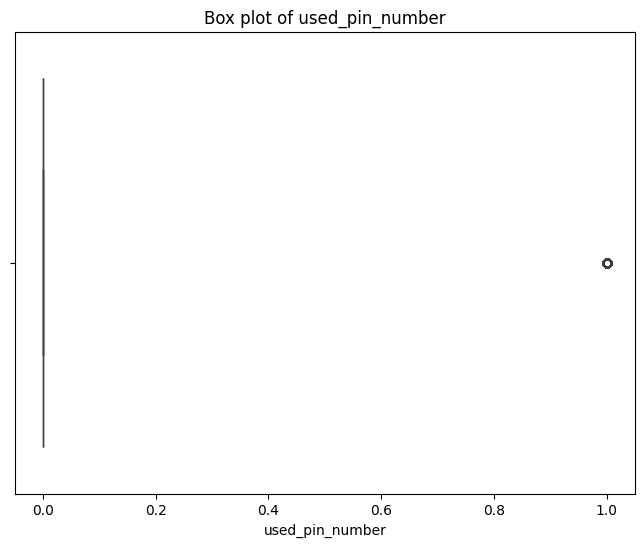

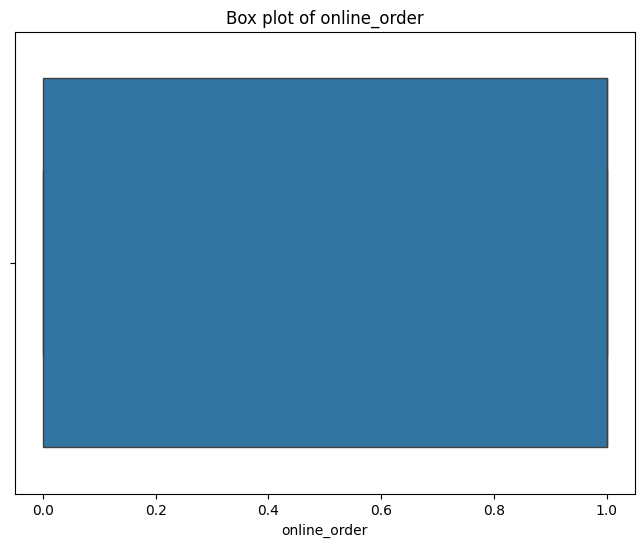

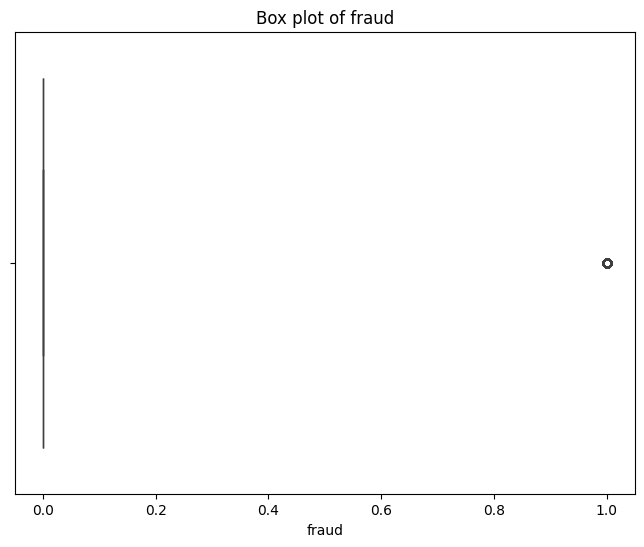

In [19]:

for column in df.columns:
    if df[column].dtype != 'object': # Check if the column is numeric
        plt.figure(figsize=(8, 6))
        sns.boxplot(x=df[column])
        plt.title(f'Box plot of {column}')
        plt.show()

# PCA

In [20]:
pca=PCA(n_components=3)
pca.fit(X)
X_pca=pca.transform(X)

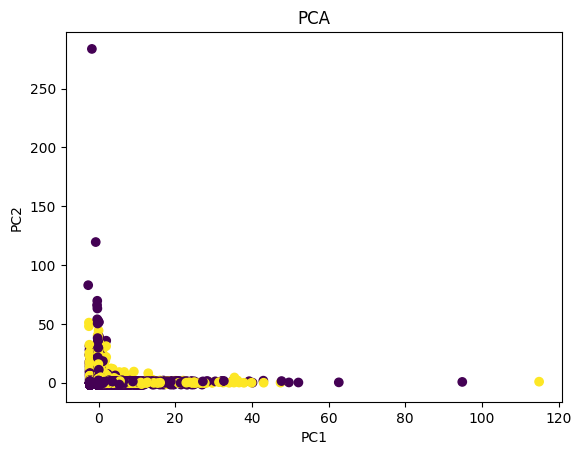

In [21]:
plt.scatter(X_pca[:,0],X_pca[:,1],c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA")
plt.show()

In [22]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

# Visualization

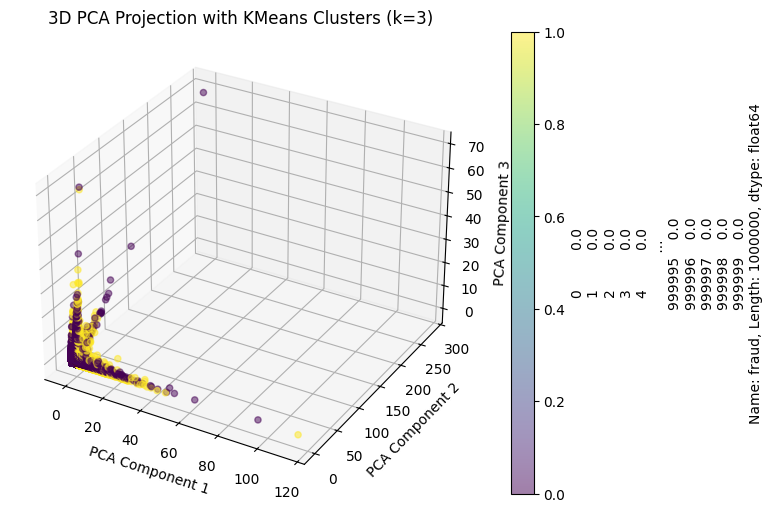

In [23]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
    c=y, cmap='viridis', alpha=0.5
)


ax.set_title("3D PCA Projection with KMeans Clusters (k=3)")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
plt.colorbar(scatter, label=y)
plt.show()

In [24]:
pd.crosstab(clusters, df['fraud'], normalize='index')

fraud,0.0,1.0
row_0,,
0,0.859113,0.140887
1,0.985072,0.014928
2,0.997286,0.002714


In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.99826


In [26]:

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182557
         1.0       0.98      1.00      0.99     17443

    accuracy                           1.00    200000
   macro avg       0.99      1.00      0.99    200000
weighted avg       1.00      1.00      1.00    200000



# T-SNE

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=250)
X_tsne = tsne.fit_transform(X)

#KMeans
plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.title("t-SNE Projection (Colored by KMeans Clusters)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df['fraud'], cmap='coolwarm', alpha=0.6)
plt.title("t-SNE Projection (Colored by Actual Fraud Labels)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.colorbar(label='Fraud (0=Not Fraud, 1=Fraud)')
plt.show()